# Peak-level supplementary data

Reproduces the ATAC peak panels ( visualises peaks and their accesibility, topic scores and TF binding profiles from the supplementary Anndata provided) Set `TOPIC`, `CELLTYPE` and
`TF` below and run top to bottom.

In [1]:
import numpy as np, pandas as pd, scanpy as sc
import seaborn as sns, matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from matplotlib.patches import Patch
from scipy.stats import zscore, spearmanr
from sklearn.preprocessing import MinMaxScaler

%matplotlib inline
sc.set_figure_params(dpi=100, dpi_save=300)

# Folder holding the files downloaded from this Zenodo record.
# Default: the same folder as this notebook.
DATA_DIR = "."
H5AD = f"{DATA_DIR}/05_supp_peak_tf_object.h5ad"
TOPIC, CELLTYPE, TF = 24, 'NPC-neuronal-like', "MYT1L"
COMPOSITE = {'Neurons (Inh)': "blue", 'NPC-neuronal-like': "#E69F00"}

TOPIC_MIN, CAP, GENE_GATE = 0.9, 500, 0.95     # peak and gene selection, as published, min topic score, num of peaks per topic and threshold of peak-gene link
VMIN, VMAX = 0.0, 0.3                          # fixed limits, so TFs stay comparable
SAVE = False

In [2]:
adata = sc.read_h5ad(H5AD)

umap = adata[adata.obs.in_umap_figure].copy()      # UMAP panels
heat = adata[adata.obs.in_heatmap_figure].copy()   # heatmap panels, a stricter set

TOPICS = list(adata.uns["topics_order"])
SCALE  = list(adata.uns["states_order"])           # min-max is taken over these 17
SHOW   = list(adata.uns["states_order_select"])    # these 12 are displayed
COLORS = {int(k): c for k, c in adata.uns["topic_colors"].items()}

print(f"{umap.n_obs:,} peaks for the UMAPs, {heat.n_obs:,} for the heatmaps, "
      f"{adata.n_vars} TFs")

110,517 peaks for the UMAPs, 20,642 for the heatmaps, 195 TFs


In [15]:
adata.uns['gene_links']

,symbol,n_peaks,total_weight
gene_id,,,
A2M,A2M,12,9.546293
AATK,AATK,52,27.047522
ABCA1,ABCA1,48,41.231812
ABCA13,ABCA13,42,31.136948
ABCA2,ABCA2,45,30.745319
...,...,...,...
ZBTB7B,ZBTB7B,25,21.436104
ZFP36,ZFP36,18,15.742668
ZFP36L1,ZFP36L1,24,20.026966


## Topic

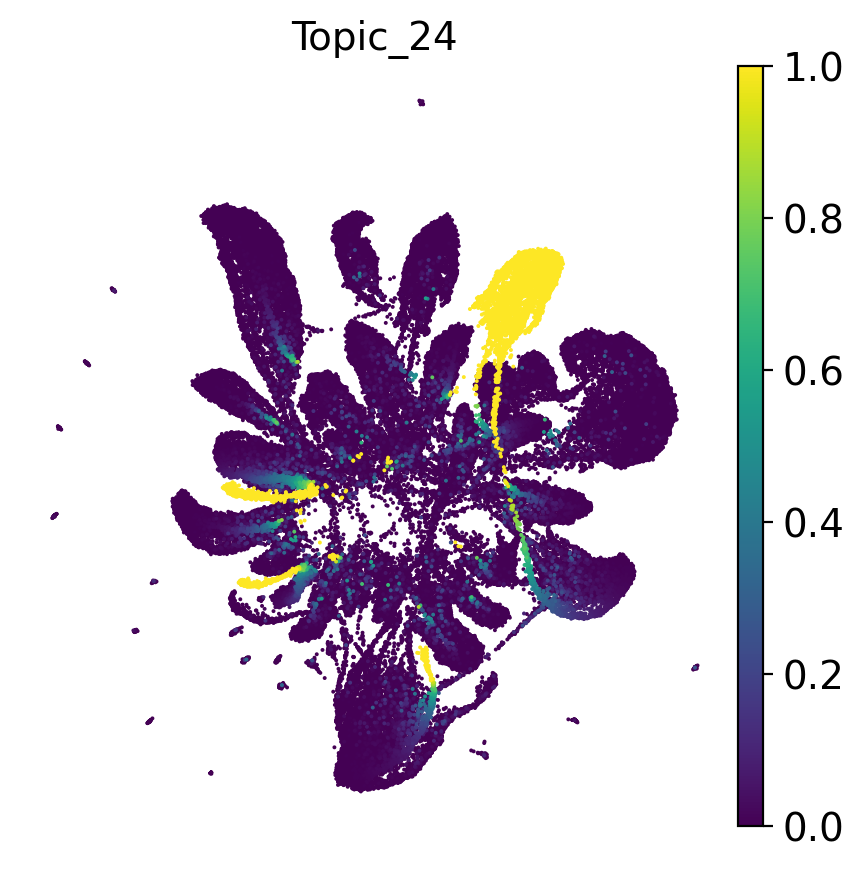

In [3]:
with plt.rc_context({"figure.figsize": (5, 5)}):
    sc.pl.umap(umap, color=f"Topic_{TOPIC}", size=8, sort_order=True,
               vmin=0, vmax="p99", frameon=False,
               save=f"_Topic_{TOPIC}.pdf" if SAVE else None)

## Accessibility in one state

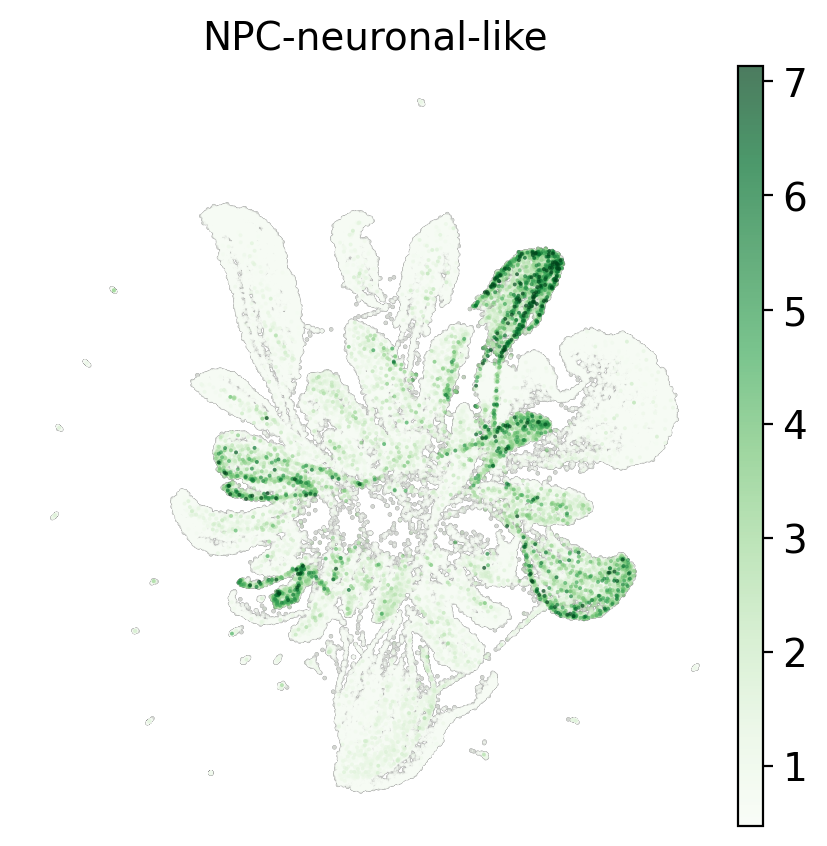

In [4]:
umap.obs["acc"] = zscore(umap.obs[CELLTYPE].to_numpy(dtype=float))

with plt.rc_context({"figure.figsize": (5, 5)}):
    sc.pl.umap(umap, color="acc", size=8, sort_order=True, cmap="Greens",
               vmin="p80", vmax="p99.9", add_outline=True,
               outline_color=("white", "grey"), frameon=False, title=CELLTYPE,
               save=f"_acc_{CELLTYPE}.pdf".replace(" ", "_") if SAVE else None)

## TF binding

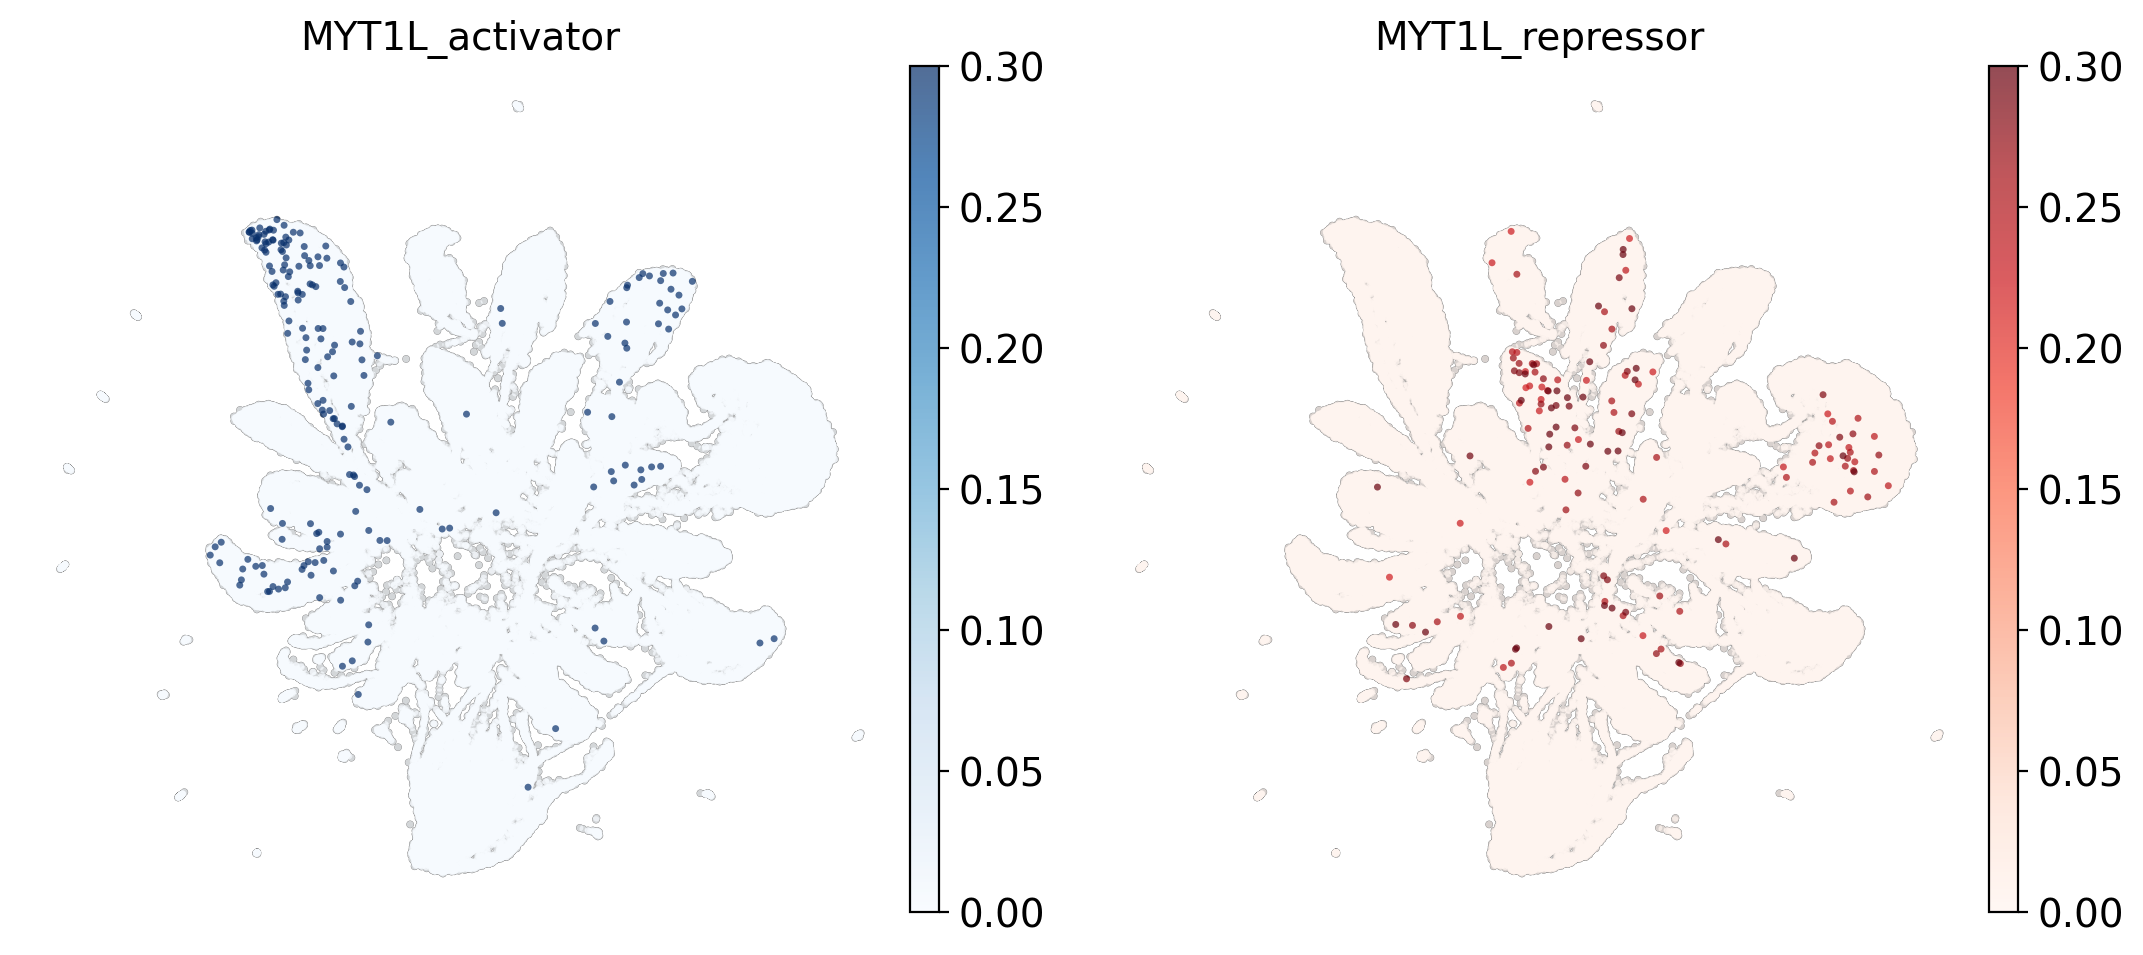

In [5]:
def binding(a, tf, kind):
    j = a.var_names.get_loc(tf)
    v = np.asarray((a.X if kind == "activator" else a.layers["repressor"])[:, j]).ravel()
    # repressor scores are stored negative, so flip them, or the colour limits pick
    # out the weakest sites instead of the strongest
    s = int(a.var["repressor_sign"].iloc[j]) if kind == "repressor" else 1
    return -v if s == -1 else v

for k in ["activator", "repressor"]:
    umap.obs[f"{TF}_{k}"] = binding(umap, TF, k)

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
for a_, k, cm in zip(ax, ["activator", "repressor"], ["Blues", "Reds"]):
    sc.pl.umap(umap, color=f"{TF}_{k}", size=25, sort_order=True, cmap=cm,
               vmin=VMIN, vmax=VMAX, add_outline=True, outline_color=("white", "grey"),
               frameon=False, show=False, ax=a_)
plt.tight_layout()
if SAVE:
    plt.savefig(f"umap_{TF}_binding.pdf", bbox_inches="tight")
plt.show()

## Two-colour composite

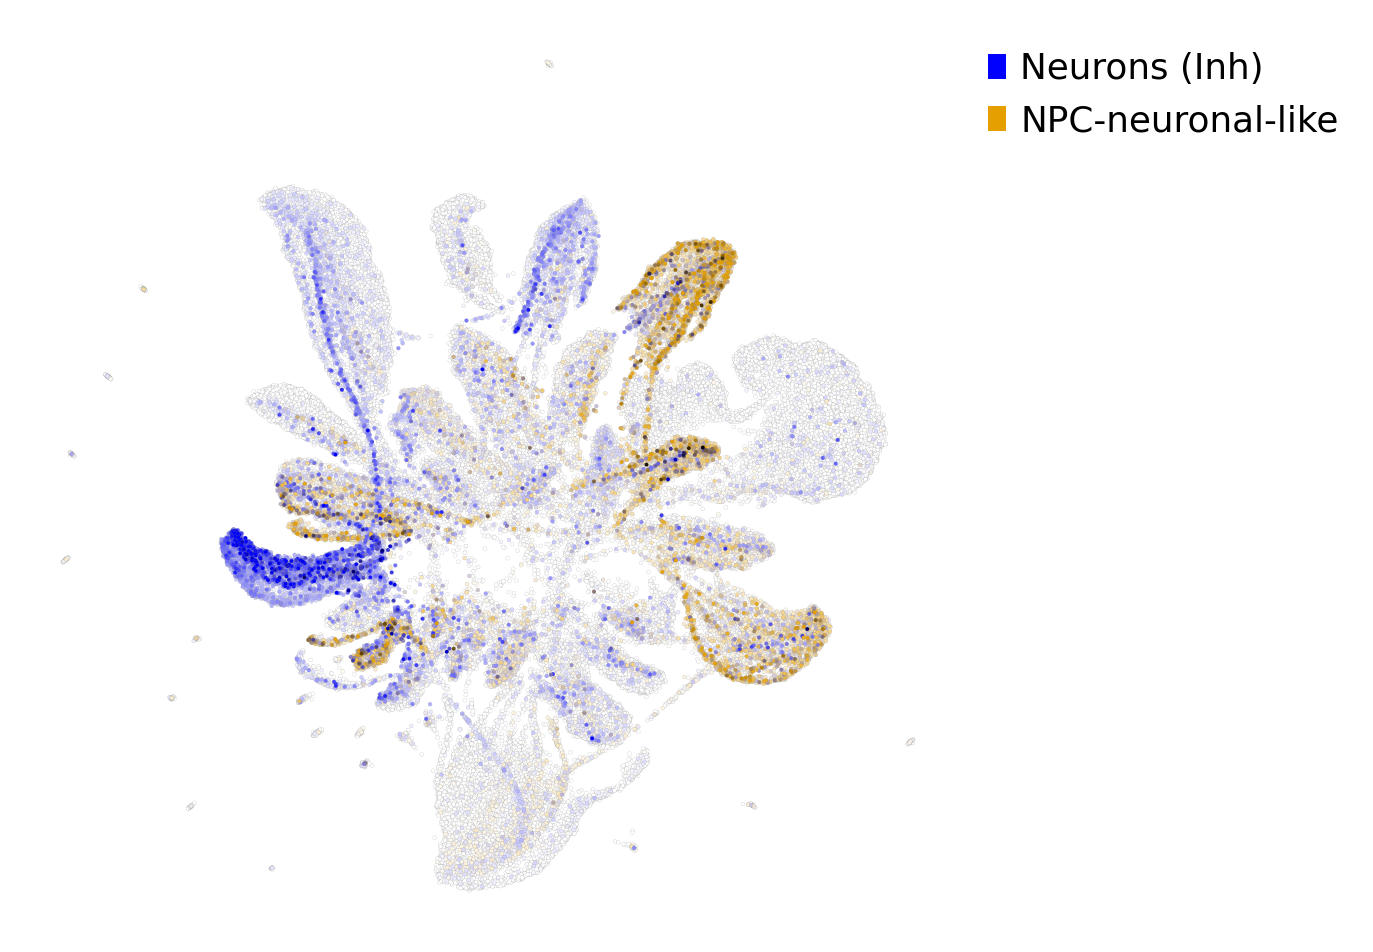

In [6]:
def composite(a, tracks, lo=80, hi=99.9, s=2):
    rgba = {k: to_rgba(c) for k, c in tracks.items()}
    cols, order_by = np.ones((a.n_obs, 4)), np.zeros(a.n_obs)
    for k in tracks:
        v = zscore(a.obs[k].to_numpy(dtype=float))
        w = np.clip((v - np.percentile(v, lo)) /
                    (np.percentile(v, hi) - np.percentile(v, lo)), 0, 1)[:, None]
        order_by += w[:, 0]
        cols[:, :3] -= cols[:, :3] * w * (1 - np.array(rgba[k][:3]))
    o = np.argsort(order_by)
    xy = np.asarray(a.obsm["X_umap"])[o]

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(xy[:, 0], xy[:, 1], c=np.clip(cols, 0, 1)[o], s=s,
               linewidths=0.05, edgecolors="gray")
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.legend(handles=[Patch(facecolor=rgba[k][:3], label=k) for k in tracks],
              loc="upper left", bbox_to_anchor=(1, 1), frameon=False)
    return ax

composite(umap, COMPOSITE)
if SAVE:
    plt.savefig("umap_composite.pdf", bbox_inches="tight")
plt.show()

## Peak accessibility heatmap

Per topic, peaks scoring above 0.9, capped at the top 500. The cap is a ceiling, so
weaker topics contribute fewer peaks.

7,385 peaks, 12 topics at the 500 cap


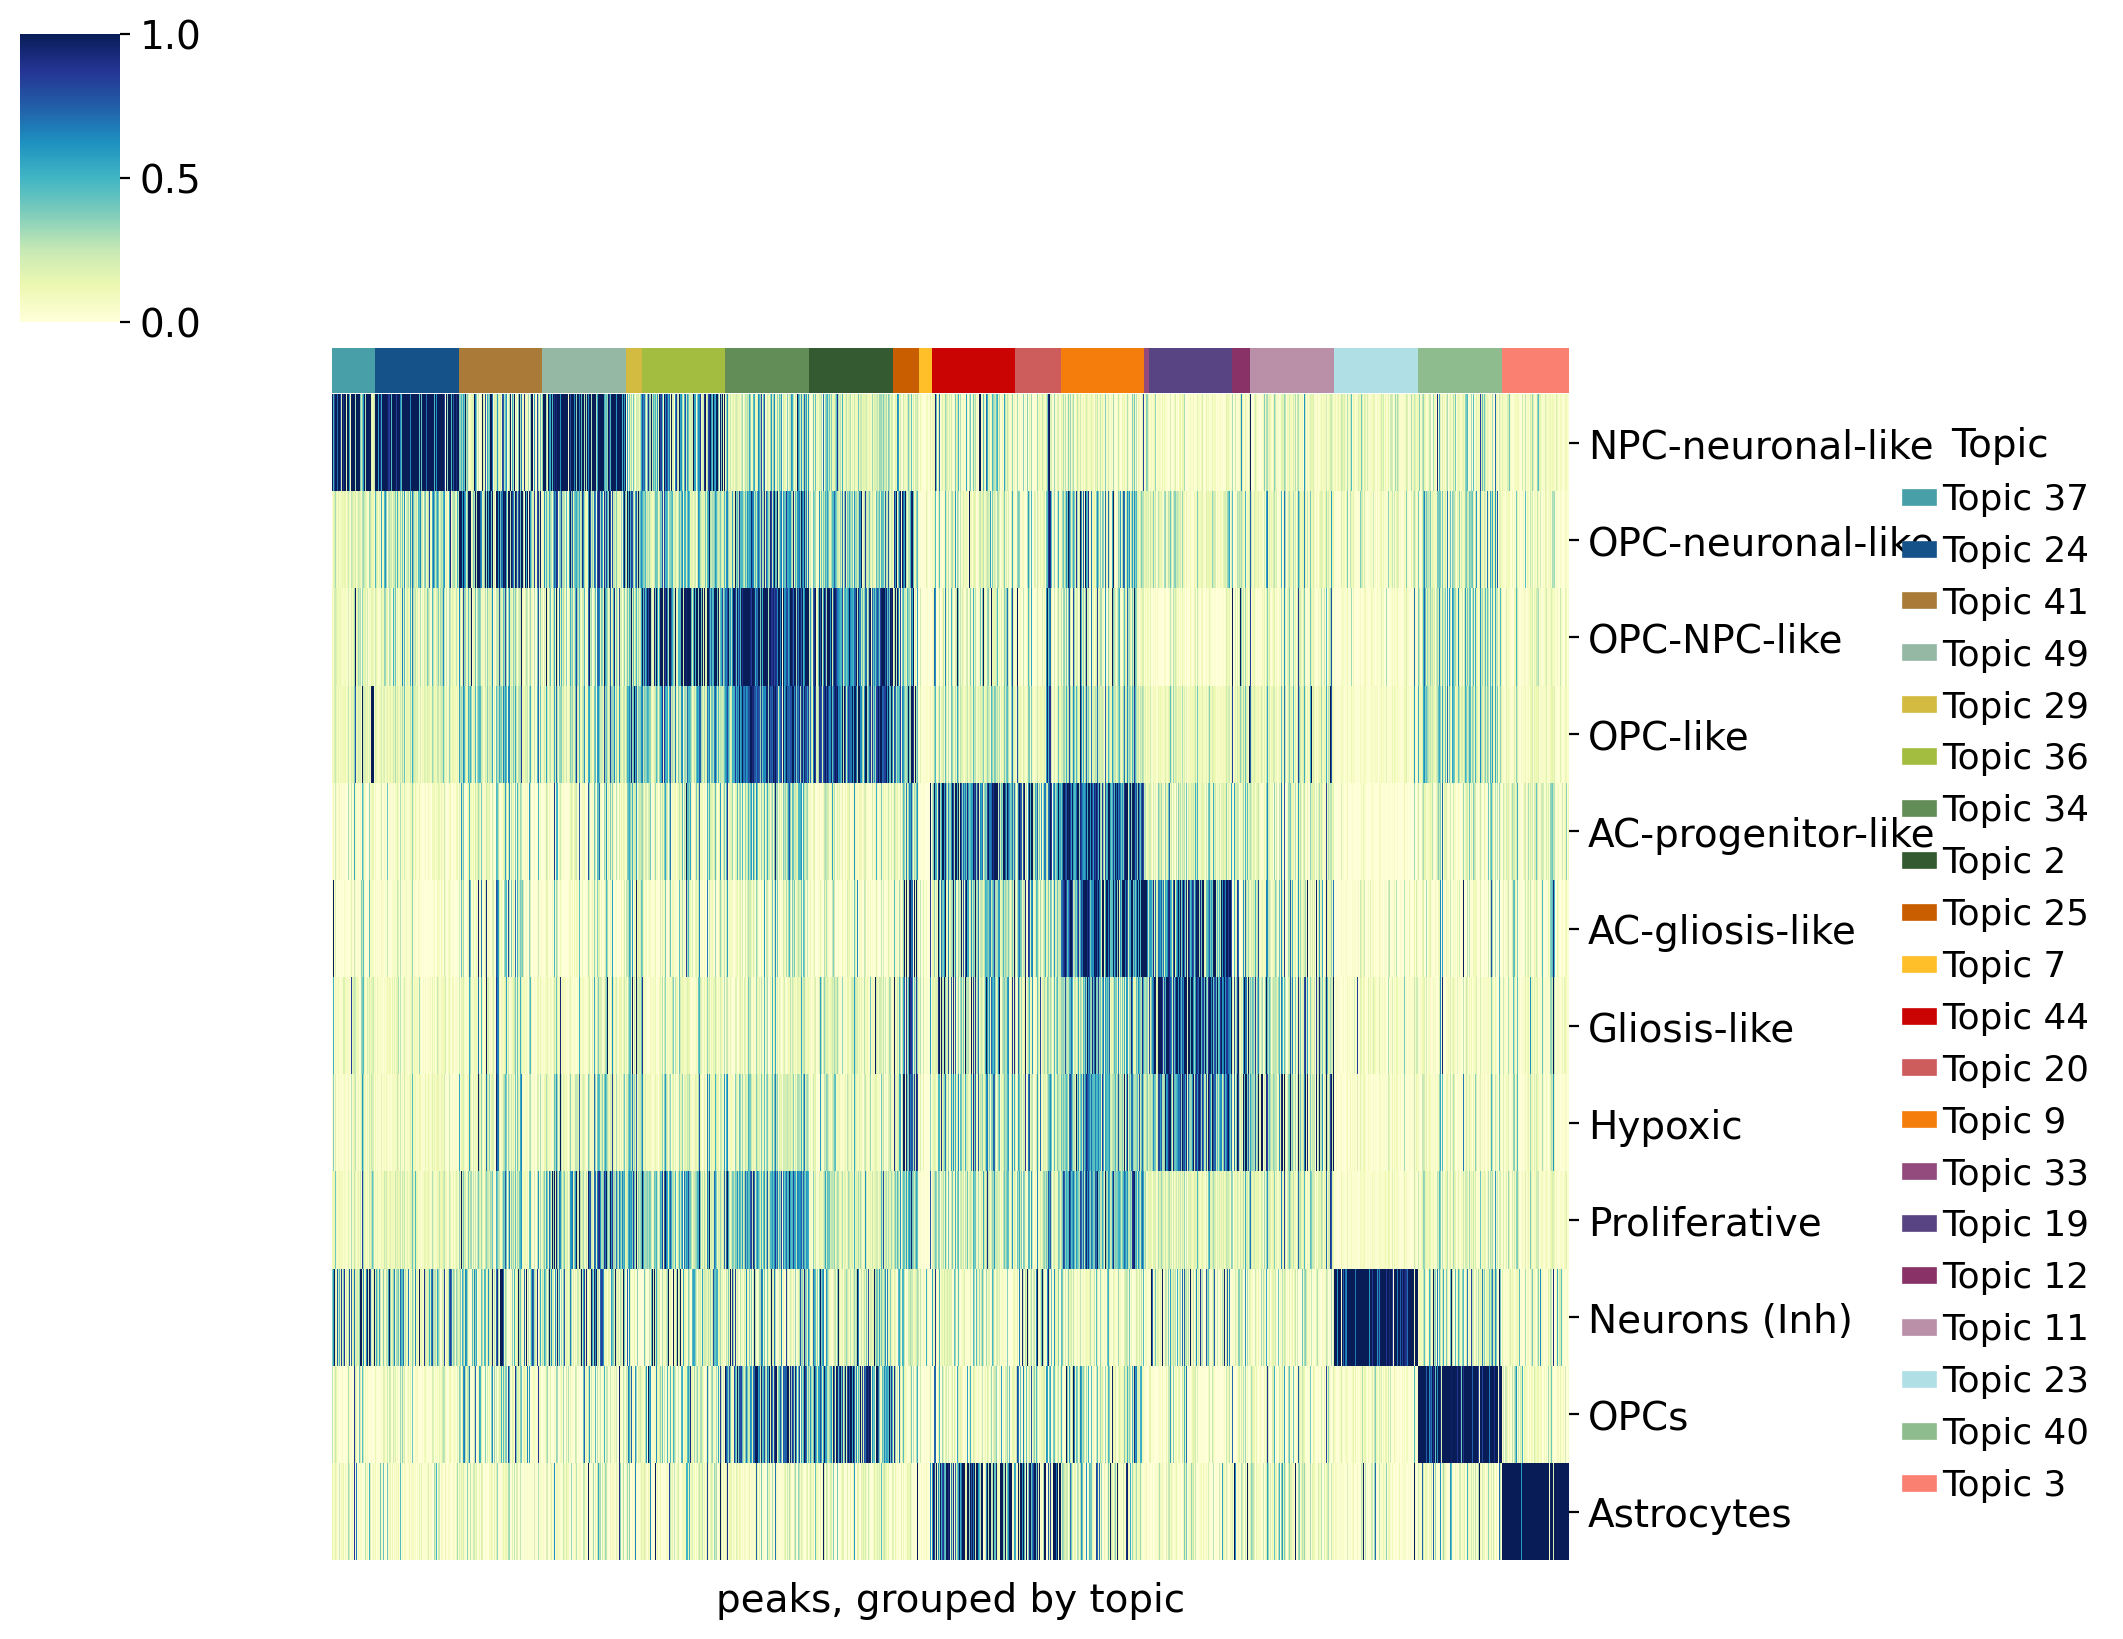

In [7]:
def topic_peaks(a, topics=None, min_score=TOPIC_MIN, cap=CAP):
    topics = TOPICS if topics is None else topics
    pk, lb = [], []
    for k in topics:
        s = a.obs[f"Topic_{k}"]
        s = s[s > min_score].sort_values(ascending=False)[:cap]
        pk += list(s.index); lb += [k] * len(s)
    return pk, np.array(lb)

def acc_heatmap(a, peaks, ref="subset"):
    # ref="subset" reproduces the figure. On a single topic use ref="pool": the row
    # total is then that topic's own signal, and dividing by it cancels what you came
    # to look at.
    cols = [f"{s}_raw" if f"{s}_raw" in a.obs.columns else s for s in SCALE]
    M = a.obs.loc[peaks, cols].to_numpy(dtype="float64").T
    R = M if ref == "subset" else a.obs[cols].to_numpy(dtype="float64").T
    rs = R.sum(axis=1, keepdims=True)
    M = MinMaxScaler().fit_transform(np.median(rs) * M / (rs + 1e-12))
    return pd.DataFrame(M, index=SCALE, columns=peaks).loc[SHOW]

peaks, labels = topic_peaks(heat)
print(f"{len(peaks):,} peaks, "
      f"{(pd.Series(labels).value_counts() == CAP).sum()} topics at the {CAP} cap")

hm = acc_heatmap(heat, peaks)
g = sns.clustermap(hm, row_cluster=False, col_cluster=False, cmap="YlGnBu",
                   vmin=0, vmax=1, figsize=(10, 8), xticklabels=False,
                   col_colors=[COLORS[k] for k in labels])
g.ax_heatmap.set_xlabel("peaks, grouped by topic")
for k in TOPICS:
    g.ax_heatmap.plot([], [], color=COLORS[k], label=f"Topic {k}", lw=6)
g.ax_heatmap.legend(title="Topic", bbox_to_anchor=(1.25, 1), loc="upper left", frameon=False)
if SAVE:
    plt.savefig("heatmap_peak_accessibility.pdf", bbox_inches="tight", dpi=1000)
plt.show()

## Gene expression heatmap

Each peak's best gene, scored by link times topic activity and kept above 0.95, then
one entry per gene and topic.

1,304 gene-topic pairs, 914 genes


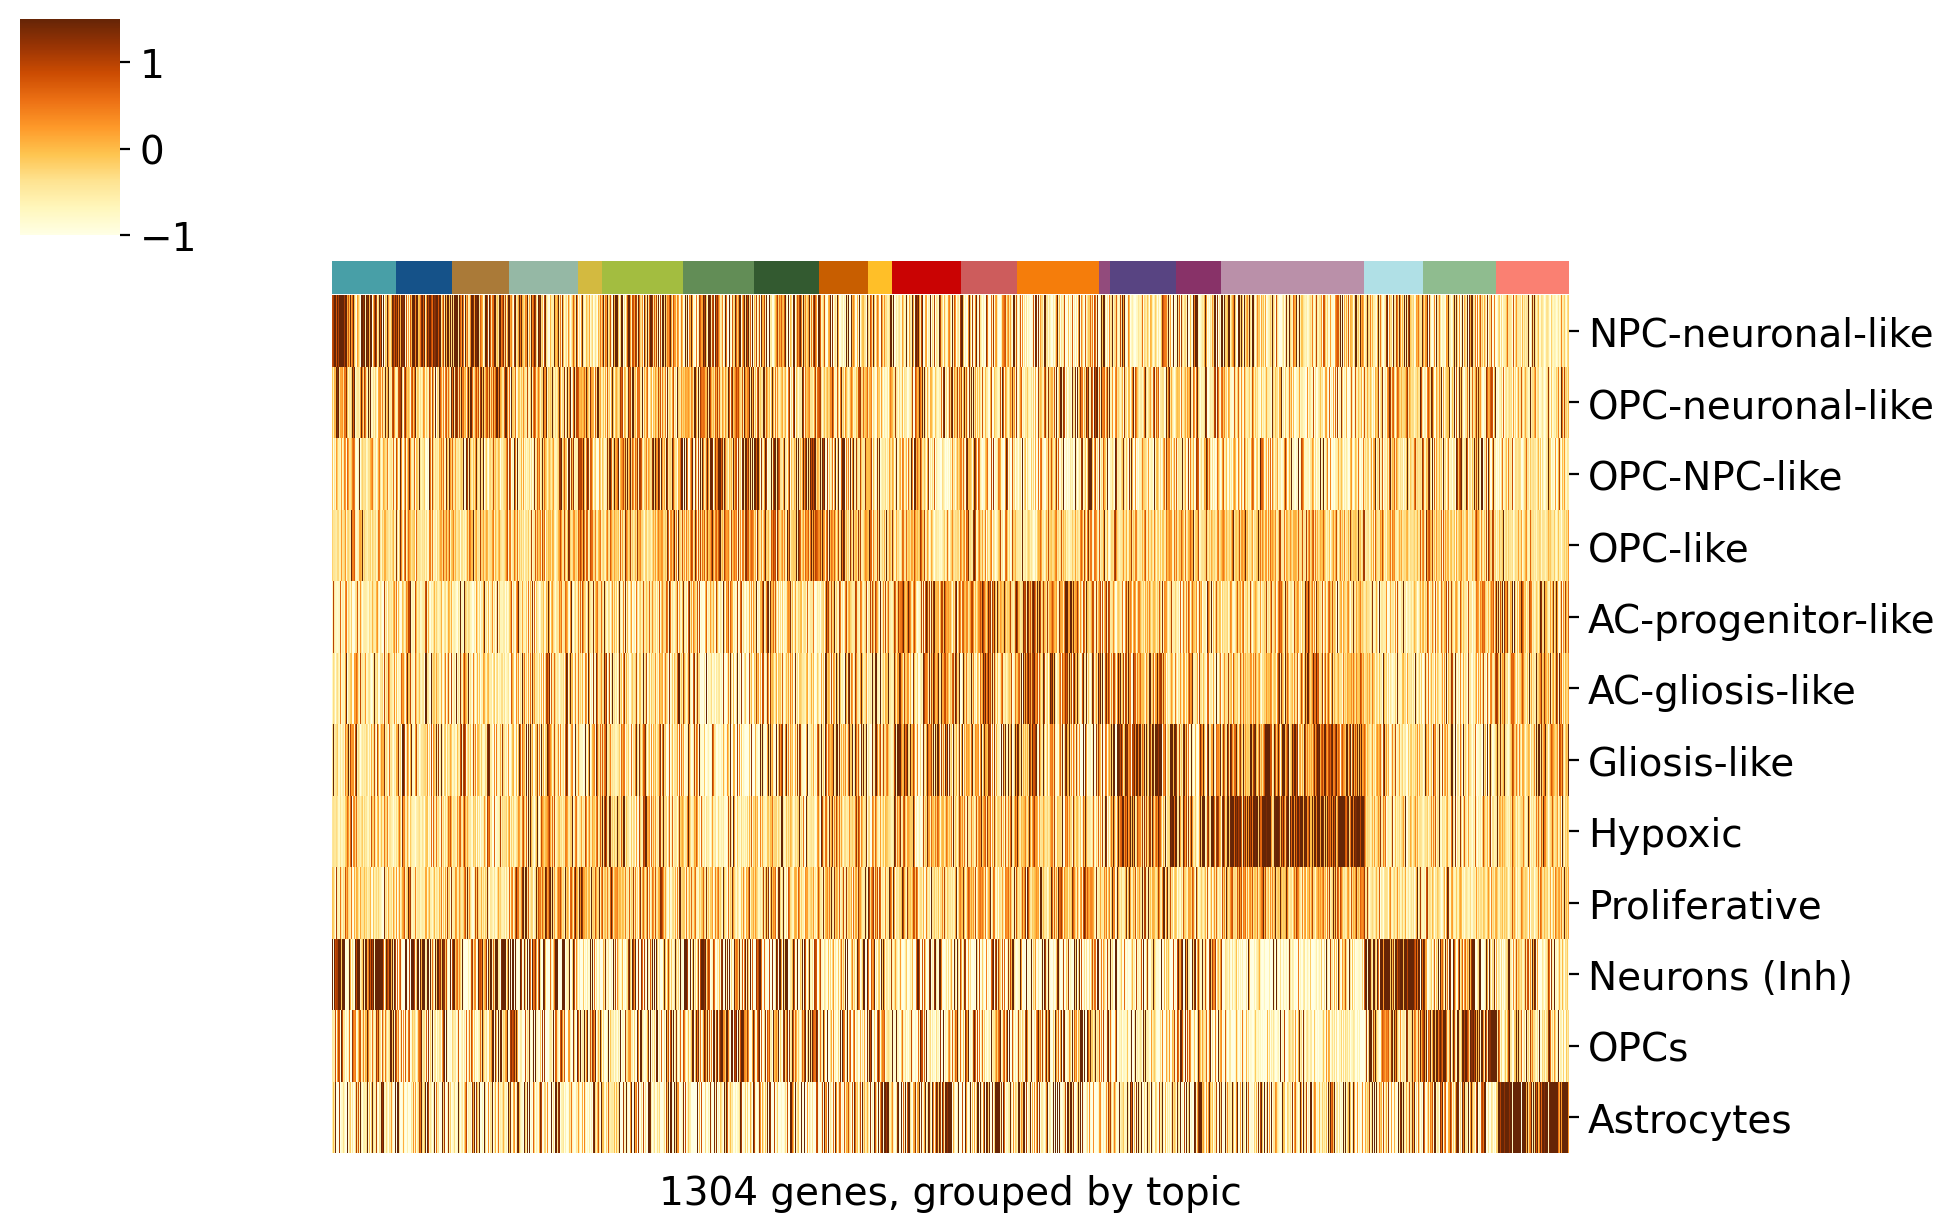

In [8]:
gl = pd.DataFrame(adata.uns["gene_links"])
genes = gl.symbol.to_numpy().astype(str)

def topic_genes(a, peaks, labels, gate=GENE_GATE):
    L = a.obsm["gene_peak_links"][a.obs_names.get_indexer(peaks)].tocsr()
    tm = a.obs.loc[peaks, [f"Topic_{k}" for k in range(50)]].to_numpy(dtype="float64")
    w = tm[np.arange(len(peaks)), labels]

    rows = []
    for i in range(L.shape[0]):
        s0, e0 = L.indptr[i], L.indptr[i + 1]
        if e0 == s0:
            continue
        gi, sc_ = L.indices[s0:e0], L.data[s0:e0] * w[i]
        keep = sc_ > gate
        if keep.any():
            gj = gi[keep][int(np.argmax(sc_[keep]))]
            rows.append({"peak": peaks[i], "Topic": labels[i], "gene_idx": int(gj),
                         "gene": genes[gj], "score": sc_[keep].max()})
    return (pd.DataFrame(rows).drop_duplicates(subset=["gene", "Topic"])
              .reset_index(drop=True))

def expr_heatmap(df):
    ge = pd.DataFrame(adata.uns["gene_expression"])
    G = ge.to_numpy(dtype="float64")
    G = np.median(G.sum(0)) * G / (G.sum(axis=0, keepdims=True) + 1e-12)
    G = zscore(G[:, [list(ge.columns).index(s) for s in SHOW]], axis=1)
    return pd.DataFrame(G[df.gene_idx.to_numpy()].T, index=SHOW, columns=df.gene.to_numpy())

gt = topic_genes(heat, peaks, labels)
gt = gt.sort_values("Topic", key=lambda s: s.map({k: i for i, k in enumerate(TOPICS)}))
print(f"{len(gt):,} gene-topic pairs, {gt.gene.nunique():,} genes")

hg = expr_heatmap(gt)
g = sns.clustermap(hg, row_cluster=False, col_cluster=False, cmap="YlOrBr",
                   vmin=-1, vmax=1.5, figsize=(10, 6), xticklabels=False,
                   col_colors=[COLORS[k] for k in gt.Topic])
g.ax_heatmap.set_xlabel(f"{hg.shape[1]} genes, grouped by topic")
if SAVE:
    plt.savefig("heatmap_gene_expression.pdf", bbox_inches="tight", dpi=1000)
plt.show()

## One link, end to end



In [9]:
cand = heat.obs[(heat.obs[f"Topic_{TOPIC}"] > TOPIC_MIN) &
                (heat.obs.linked_gene_score > GENE_GATE)]
peak = (cand[f"Topic_{TOPIC}"] * cand.linked_gene_score).idxmax()
gene = str(cand.loc[peak, "linked_gene"])

L = adata.obsm["gene_peak_links"].tocsr()
row = L.getrow(adata.obs_names.get_loc(peak))
col = L.tocsc().getcol(int(np.where(genes == gene)[0][0]))
here = col.data[np.where(adata.obs_names[col.indices] == peak)[0][0]]

print(f"{peak} -> {gene}")
print(f"  topic {TOPIC} score {cand.loc[peak, f'Topic_{TOPIC}']:.3f}, "
      f"summed over all 50 topics {cand.loc[peak, 'topic_sum']:.3f}")
print(f"  link {here:.3f}, ranked {(col.data > here).sum() + 1} of {col.nnz} peaks "
      f"linked to {gene}")
print(f"  {row.nnz} gene(s) linked to this peak, "
      f"{gene} takes {here / row.data.sum():.0%} of its link weight")

chr1:215103470:215103970:501:*:56429 -> KCNK2
  topic 24 score 1.000, summed over all 50 topics 1.006
  link 1.000, ranked 1 of 21 peaks linked to KCNK2
  1 gene(s) linked to this peak, KCNK2 takes 100% of its link weight


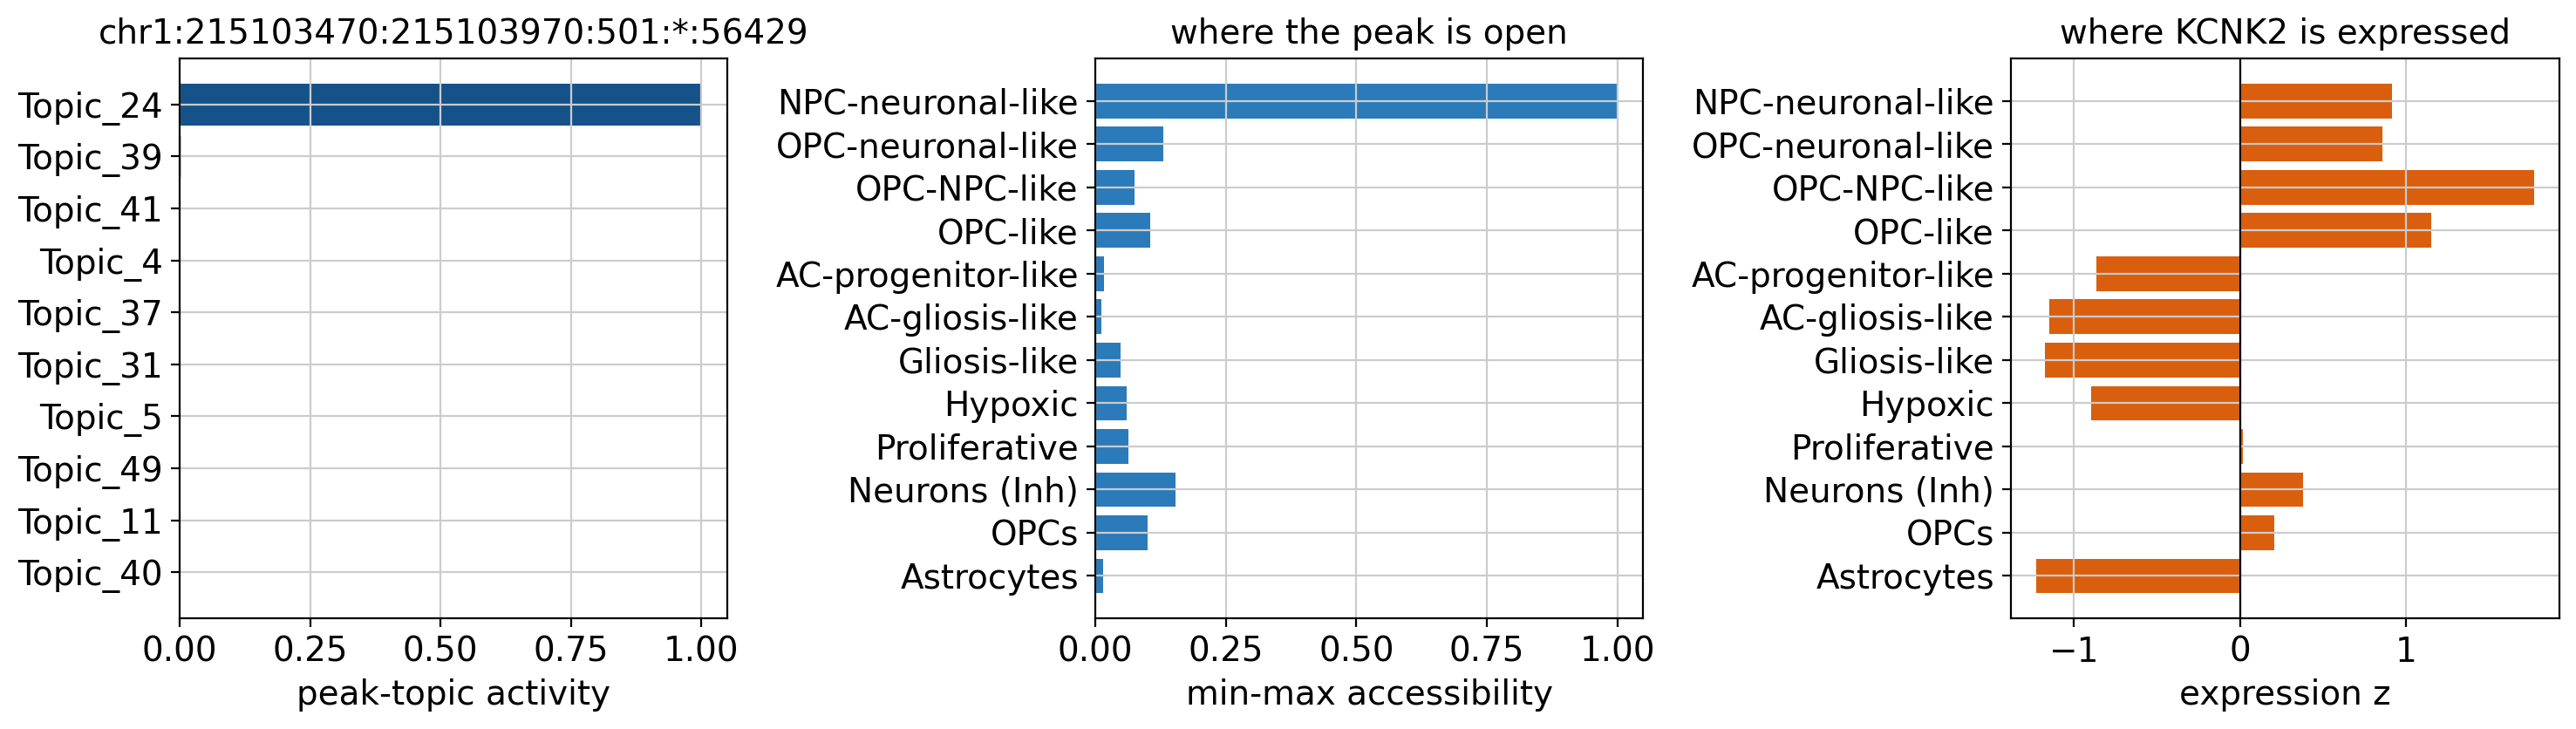

Spearman 0.80


In [10]:
gi = int(np.where(genes == gene)[0][0])
prof = heat.obs.loc[peak, [f"Topic_{k}" for k in range(50)]].astype(float)
acc  = acc_heatmap(heat, [peak], ref="pool")[peak]
expr = expr_heatmap(pd.DataFrame({"gene_idx": [gi], "gene": [gene]}))[gene]

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))

t = prof.sort_values(ascending=False).head(10)[::-1]
ax[0].barh(t.index, t.to_numpy(),
           color=[COLORS.get(TOPIC, "grey") if n == f"Topic_{TOPIC}" else "lightgrey"
                  for n in t.index])
ax[0].set_title(peak); ax[0].set_xlabel("peak-topic activity")

ax[1].barh(acc.index[::-1], acc.to_numpy()[::-1], color="#2b7bba")
ax[1].set_title("where the peak is open"); ax[1].set_xlabel("min-max accessibility")

ax[2].barh(expr.index[::-1], expr.to_numpy()[::-1], color="#d95f0e")
ax[2].axvline(0, c="k", lw=0.8)
ax[2].set_title(f"where {gene} is expressed"); ax[2].set_xlabel("expression z")

plt.tight_layout()
if SAVE:
    plt.savefig(f"link_example_Topic{TOPIC}_{gene}.pdf", bbox_inches="tight")
plt.show()

print(f"Spearman {spearmanr(acc.to_numpy(), expr.to_numpy()).correlation:.2f}")